In [8]:
import pandas as pd

df = pd.read_csv("diamonds.csv")
df.shape

(53940, 11)

In [9]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [10]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')

In [11]:
#The first column is an index ("Unnamed:0") and thus we are going to remove it

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 5.1 MB


In [12]:
#The first column seems to be just index

data = df.drop("Unnamed: 0", axis =1)
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [13]:
#Dropping dimensionless diamonds

data = data.drop(data[data["x"]==0].index)
data = data.drop(data[data["y"]==0].index)
data = data.drop(data[data["z"]==0].index)
data.shape

(53920, 10)

In [14]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

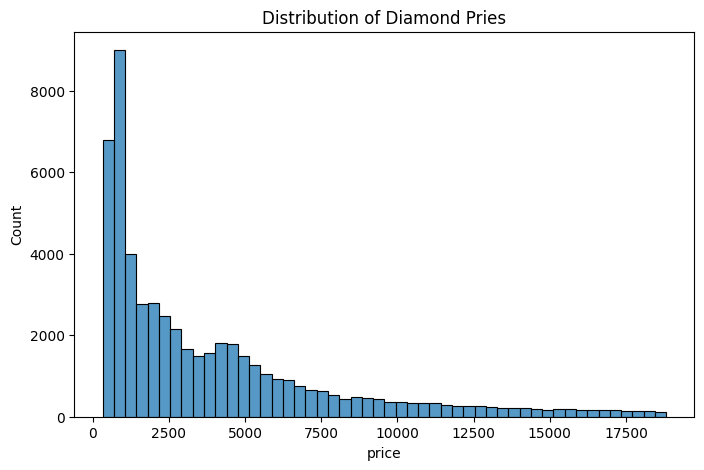

In [16]:
# Price Distribution (Visualiztion 1)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50)
plt.title("Distribution of Diamond Pries")
plt.show()


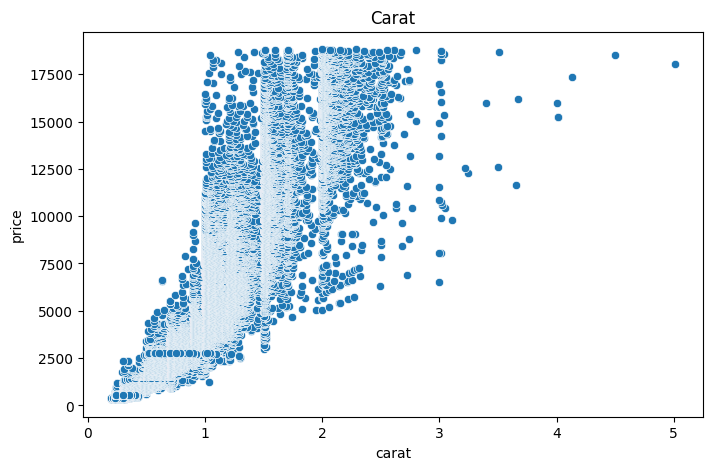

In [17]:
# Carat vs Price (Visualization 2)

plt.figure(figsize=(8,5))
sns.scatterplot(x="carat", y = "price", data=df)
plt.title("Carat")
plt.show()

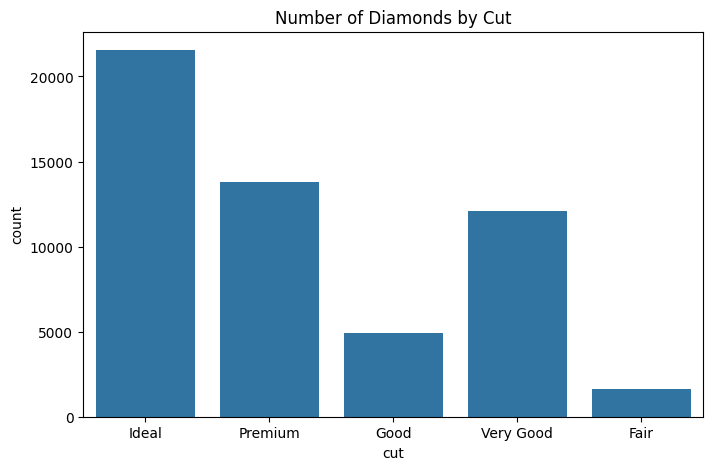

In [18]:
# Diamonds by Cuts ( Visualization 3)

plt.figure(figsize=(8,5))
sns.countplot(x="cut", data=df)
plt.title("Number of Diamonds by Cut")
plt.show()

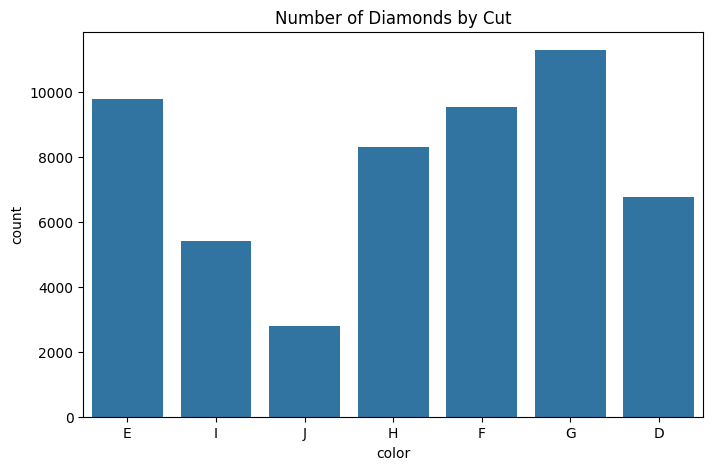

In [19]:
# Diamonds by Color (Visualization 4)

plt.figure(figsize=(8,5))
sns.countplot(x="color", data=df)
plt.title("Number of Diamonds by Cut")
plt.show()

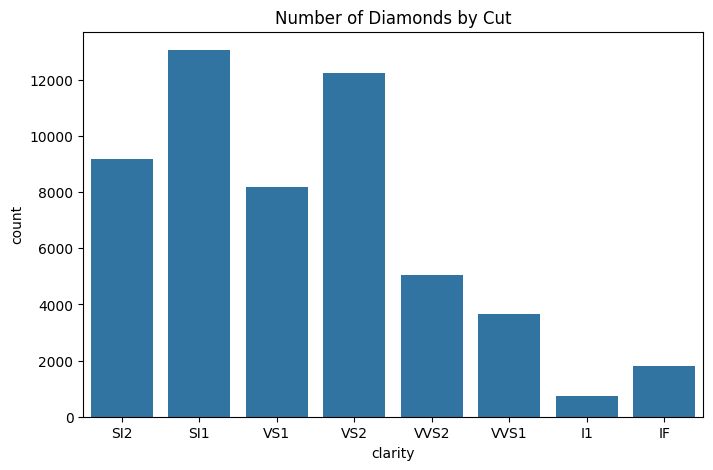

In [20]:
# Diamonds by Clarity  (Visualization 5)

plt.figure(figsize=(8,5))
sns.countplot(x="clarity", data=df)
plt.title("Number of Diamonds by Cut")
plt.show()

In [21]:
df.dtypes

Unnamed: 0      int64
carat         float64
cut               str
color             str
clarity           str
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
dtype: object

In [22]:
!pip install scikit-learn

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["cut"] = le.fit_transform(df["cut"])
df["color"] = le.fit_transform(df["color"])
df["clarity"] = le.fit_transform(df["clarity"])


In [24]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [25]:
x = df.drop("price", axis=1)
y= df["price"]

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
import sys 
print(sys.executable)

c:\Users\Pc\miniconda3\python.exe


In [29]:
import sklearn
print(sklearn.__version__)

1.9.0


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x = df.drop("price", axis=1)
y = df["price"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [32]:
from sklearn.linear_model import LinearRegression
print("Import OK")

Import OK


In [33]:
lr = LinearRegression()
print("Object Created")

Object Created


In [34]:
lr.fit(x_train, y_train)
print("Model Trained")

Model Trained


In [35]:
#make predictions

y_pred = lr.predict(x_test)

In [36]:
#check accuracy

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(r2)

0.8860134363272643


In [37]:
# check error measures

from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))

MAE 862.9888776244618
MSE 1812024.050548116


In [38]:
#LR

r2_score(y_test, y_pred)                #explains about 88% of price variation

0.8860134363272643

In [39]:
#Training Decision Tree Regressor and comparing it with LR

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred_dt))                  # perfectly fitting data

0.9999668597860654


In [59]:
# Training a Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=20, max_depth=10, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print(r2_score(y_test, y_pred_rf))                   # slightly better than Decision Tree

0.9793930177089126


In [41]:
# Choosing Random Forest Regressor as the final model because it has the highest R*2 score

In [60]:
import pickle

pickle.dump(rf, open("diamond_model.pkl", "wb"))

In [43]:
from sklearn.preprocessing import LabelEncoder

for col in ["cut", "color", "clarity"]:
    print(col)
    print(df[col].unique())

cut
[2 3 1 4 0]
color
[1 5 6 4 2 3 0]
clarity
[3 2 4 5 7 6 0 1]


In [44]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')

In [45]:
df = df.drop("Unnamed: 0", axis=1)

In [46]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [47]:
x = df.drop("price", axis=1)
y = df["price"]

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [49]:
rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [50]:
import pickle

pickle.dump(rf, open("diamond_model.pkl", "wb"))

In [51]:
x.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'], dtype='str')

In [52]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [53]:
df.dtypes

carat      float64
cut          int64
color        int64
clarity      int64
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [54]:
print(sorted(df["cut"].unique()))
print(sorted(df["color"].unique()))
print(sorted(df["clarity"].unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [61]:
import os

size = os.path.getsize("diamond_model.pkl")/(1024*1024)
print(f"File size : {size:.2f} MB")

File size : 2.43 MB
